Install & Import


In [1]:
# Import everything we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


Load Dataset

In [2]:
# This dataset has information about 303 patients

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# These are the column names for this dataset
column_names = [
    'age',        # age in years
    'sex',        # 1=male, 0=female
    'cp',         # chest pain type (0-3)
    'trestbps',   # resting blood pressure
    'chol',       # cholesterol level
    'fbs',        # fasting blood sugar > 120mg
    'restecg',    # resting ECG result
    'thalach',    # maximum heart rate
    'exang',      # exercise induced chest pain
    'oldpeak',    # ST depression from exercise
    'slope',      # slope of ST segment
    'ca',         # number of blood vessels
    'thal',       # thalassemia type
    'target'      # 0=no disease, 1,2,3,4=disease
]

# na_values='?' means treat '?' as missing value
df = pd.read_csv(url, names=column_names, na_values='?')

print("Dataset loaded!")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("")
print("First 5 rows:")
print(df.head())

Dataset loaded!
Rows: 303
Columns: 14

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


Clean the Data

In [3]:
# Step 1: Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Step 2: Fill missing values with the median
# Median = middle value when sorted
# We use median instead of mean because it is not affected by extreme values
for column in df.columns:
    if df[column].isnull().sum() > 0:
        median_value = df[column].median()
        df[column].fillna(median_value, inplace=True)
        print("Fixed missing values in:", column)

# Step 3: Convert target to simple 0 or 1
# Original: 0 = no disease, 1/2/3/4 = has disease
# New: 0 = no disease, 1 = has disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("")
print("After cleaning:")
print("Missing values:", df.isnull().sum().sum())
print("")
print("How many have heart disease?")
print(df['target'].value_counts())
print("0 = No Disease, 1 = Has Disease")

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Fixed missing values in: ca
Fixed missing values in: thal

After cleaning:
Missing values: 0

How many have heart disease?
target
0    164
1    139
Name: count, dtype: int64
0 = No Disease, 1 = Has Disease


Explore the Data (EDA)

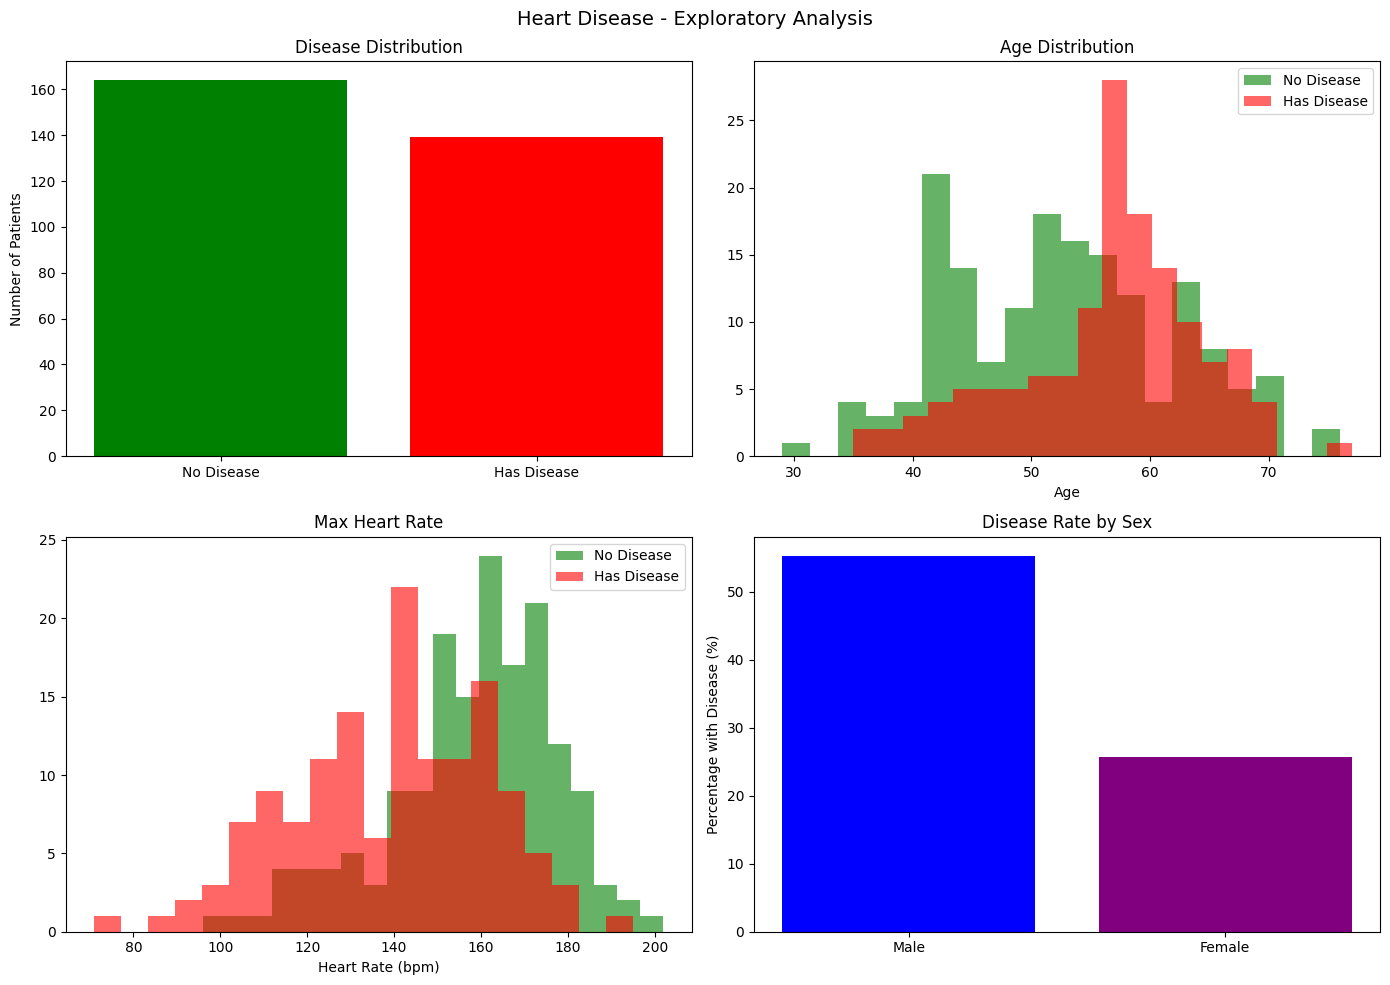

EDA charts saved!


In [4]:
# Create a chart with 4 sub-plots to explore the data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: How many have disease vs do not
disease_counts = df['target'].value_counts()
axes[0][0].bar(
    ['No Disease', 'Has Disease'],
    disease_counts.values,
    color=['green', 'red']
)
axes[0][0].set_title('Disease Distribution')
axes[0][0].set_ylabel('Number of Patients')

# Chart 2: Age of patients with and without disease
no_disease_age   = df[df['target'] == 0]['age']
with_disease_age = df[df['target'] == 1]['age']
axes[0][1].hist(no_disease_age, bins=20, alpha=0.6,
                color='green', label='No Disease')
axes[0][1].hist(with_disease_age, bins=20, alpha=0.6,
                color='red', label='Has Disease')
axes[0][1].set_title('Age Distribution')
axes[0][1].set_xlabel('Age')
axes[0][1].legend()

# Chart 3: Max heart rate for disease vs no disease
no_disease_hr   = df[df['target'] == 0]['thalach']
with_disease_hr = df[df['target'] == 1]['thalach']
axes[1][0].hist(no_disease_hr, bins=20, alpha=0.6,
                color='green', label='No Disease')
axes[1][0].hist(with_disease_hr, bins=20, alpha=0.6,
                color='red', label='Has Disease')
axes[1][0].set_title('Max Heart Rate')
axes[1][0].set_xlabel('Heart Rate (bpm)')
axes[1][0].legend()

# Chart 4: Disease rate by sex
male_data   = df[df['sex'] == 1]
female_data = df[df['sex'] == 0]

male_disease_rate   = male_data['target'].mean() * 100
female_disease_rate = female_data['target'].mean() * 100

axes[1][1].bar(['Male', 'Female'],
               [male_disease_rate, female_disease_rate],
               color=['blue', 'purple'])
axes[1][1].set_title('Disease Rate by Sex')
axes[1][1].set_ylabel('Percentage with Disease (%)')

plt.suptitle('Heart Disease - Exploratory Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('task3_eda.png')
plt.show()

print("EDA charts saved!")

Prepare Data for Training

In [5]:
# Separate features (inputs) from target (output)

# X = all columns except target
X = df.drop('target', axis=1)

# y = only the target column
y = df['target']

# Split into train and test
# test_size=0.2 means 20% goes to testing
# stratify=y means keep same disease ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the features
# StandardScaler makes all features have mean=0 and std=1
# This helps models work better when features have different ranges
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn scale from train, then apply
X_test  = scaler.transform(X_test)        # only apply (don't learn from test!)

print("Data ready for training!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Data ready for training!
Training samples: 242
Testing samples: 61


Train Models

In [6]:
# Train Model 1: Logistic Regression
# Logistic Regression predicts probability of disease (0 to 1)

logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_accuracy    = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression trained!")
print("Accuracy:", round(logistic_accuracy * 100, 2), "%")

print("")

# Train Model 2: Decision Tree
# Decision Tree makes yes/no questions to classify

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
tree_accuracy    = accuracy_score(y_test, tree_predictions)

print("Decision Tree trained!")
print("Accuracy:", round(tree_accuracy * 100, 2), "%")

print("")
print("COMPARISON:")
print("Logistic Regression:", round(logistic_accuracy * 100, 2), "%")
print("Decision Tree:      ", round(tree_accuracy * 100, 2), "%")

Logistic Regression trained!
Accuracy: 86.89 %

Decision Tree trained!
Accuracy: 77.05 %

COMPARISON:
Logistic Regression: 86.89 %
Decision Tree:       77.05 %


Confusion Matrix

Confusion Matrix (Logistic Regression):
[[27  6]
 [ 2 26]]

Row 0 = Actually No Disease
Row 1 = Actually Has Disease
Col 0 = Predicted No Disease
Col 1 = Predicted Has Disease


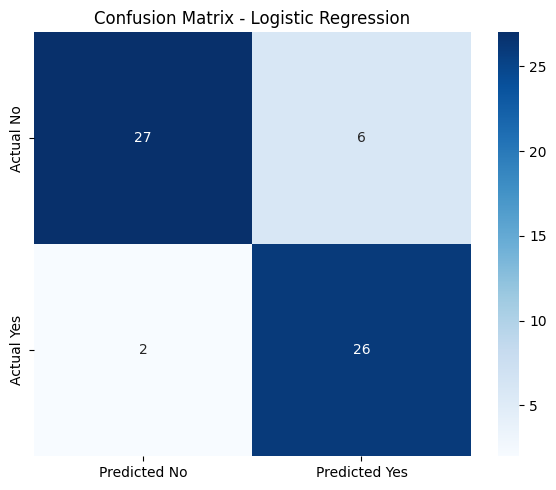

Correctly predicted No Disease: 27
Correctly predicted Disease:    26
Missed disease (False Negative): 2 <-- Most dangerous!
False alarm (False Positive):    6


In [7]:
# A confusion matrix shows us:
# How many patients we predicted correctly
# How many we got wrong

# --- Logistic Regression Confusion Matrix ---
cm = confusion_matrix(y_test, logistic_predictions)

print("Confusion Matrix (Logistic Regression):")
print(cm)
print("")
print("Row 0 = Actually No Disease")
print("Row 1 = Actually Has Disease")
print("Col 0 = Predicted No Disease")
print("Col 1 = Predicted Has Disease")

# Draw the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,      # show numbers
    fmt='d',         # integer format
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('task3_confusion_matrix.png')
plt.show()

# Extract values from confusion matrix
true_negative  = cm[0][0]   # correctly predicted no disease
false_positive = cm[0][1]   # said disease but was healthy
false_negative = cm[1][0]   # said healthy but had disease (DANGEROUS!)
true_positive  = cm[1][1]   # correctly predicted disease

print("Correctly predicted No Disease:", true_negative)
print("Correctly predicted Disease:   ", true_positive)
print("Missed disease (False Negative):", false_negative, "<-- Most dangerous!")
print("False alarm (False Positive):   ", false_positive)

ROC Curve

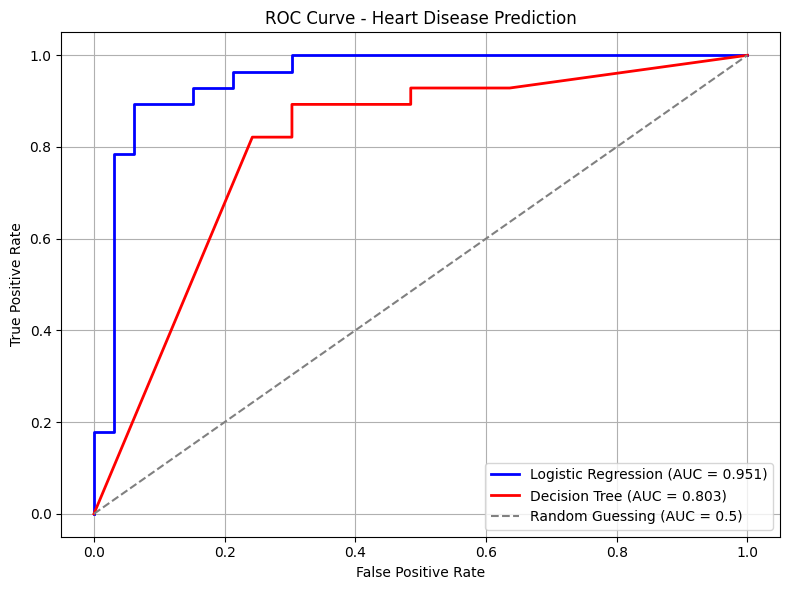

ROC curve saved!
Logistic Regression AUC: 0.951
Decision Tree AUC:       0.803


In [8]:
# ROC curve shows model performance at all decision thresholds
# AUC = Area Under the Curve
# AUC of 1.0 = perfect, AUC of 0.5 = random guessing

# Get probabilities (not just 0/1 predictions)
logistic_probs = logistic_model.predict_proba(X_test)[:, 1]
tree_probs     = tree_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve points
fpr_lr, tpr_lr, _ = roc_curve(y_test, logistic_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, tree_probs)

# Calculate AUC scores
auc_lr = roc_auc_score(y_test, logistic_probs)
auc_dt = roc_auc_score(y_test, tree_probs)

# Draw the ROC curve
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, color='blue', linewidth=2,
         label='Logistic Regression (AUC = ' + str(round(auc_lr, 3)) + ')')

plt.plot(fpr_dt, tpr_dt, color='red', linewidth=2,
         label='Decision Tree (AUC = ' + str(round(auc_dt, 3)) + ')')

# Diagonal line = random guessing
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Guessing (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Heart Disease Prediction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('task3_roc_curve.png')
plt.show()

print("ROC curve saved!")
print("Logistic Regression AUC:", round(auc_lr, 3))
print("Decision Tree AUC:      ", round(auc_dt, 3))

Feature Importance

Feature Importances:
 Feature  Importance
    thal    0.378859
      cp    0.151595
      ca    0.116874
     age    0.092980
    chol    0.082157
 oldpeak    0.065886
 thalach    0.041809
   slope    0.031752
     sex    0.026142
     fbs    0.008802
trestbps    0.003144
   exang    0.000000
 restecg    0.000000


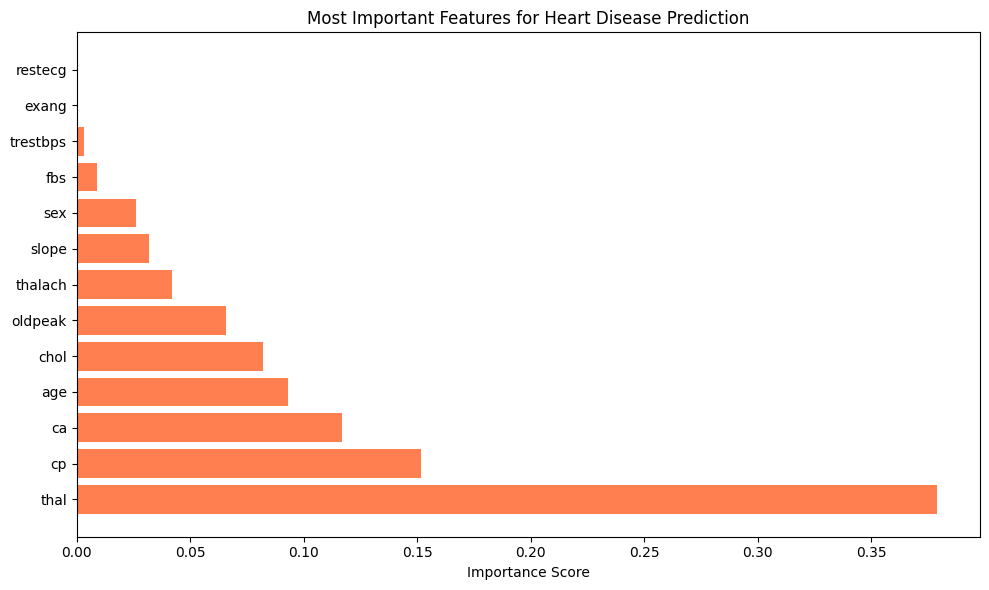

Feature importance chart saved!


In [9]:
# Which health factors are most important for predicting disease?
# We use the Decision Tree's built-in feature importance

feature_names = df.drop('target', axis=1).columns

# Get importance scores from the tree
importance_scores = tree_model.feature_importances_

# Create a table of features and their importance
importance_table = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
})

# Sort by importance (highest first)
importance_table = importance_table.sort_values('Importance', ascending=False)

print("Feature Importances:")
print(importance_table.to_string(index=False))

# Draw bar chart
plt.figure(figsize=(10, 6))
plt.barh(
    importance_table['Feature'],
    importance_table['Importance'],
    color='coral'
)
plt.xlabel('Importance Score')
plt.title('Most Important Features for Heart Disease Prediction')
plt.tight_layout()
plt.savefig('task3_feature_importance.png')
plt.show()

print("Feature importance chart saved!")